lipschitz constant must be lower - monte carlo estimation of the lipschitz constant

# Exercise 3: Adversarial Attacks I

**Group Members (please state here)**:
1.   Yi-Hui Fan
2.   Avik Das
3.   

**Please submit as groups of no more than three students.**

---

This exercise will help you explore and understand adversarial attacks on neural networks. You will implement fully connected and convolutional networks, calculate their Lipschitz constants both analytically and empirically, and conduct adversarial attacks causing misclassifications by the models.

<br>

## Deliverables

**Task 1**: Implementation and training of a fully connected network and a convolutional neural network

**Task 2**: Analytic computation of the Lipschitz constants

**Task 3**: Numeric computation of the Lipschitz constants

**Task 4**: Implementation and evaluation of the FGSM and Noise Tuning attacks

<br>

**End your notebook with a brief report documenting your findings, experiments and observations.**

## 0 - Imports

In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt

## 1 - Training Networks

### 1a - Fully Connected Neural Network

#### Instructions
- Implement and train a fully connected neural network (FCN) with an architecture of your choice
- Use the MNIST handwritten digit dataset

Train: (60000, 784), Test: (10000, 784)


Model: "FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8863 - loss: 0.3701 - val_accuracy: 0.9675 - val_loss: 0.1077
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9546 - loss: 0.1532 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9675 - loss: 0.1113 - val_accuracy: 0.9785 - val_loss: 0.0774
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9729 - loss: 0.0916 - val_accuracy: 0.9775 - val_loss: 0.0792
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accuracy: 0.9785 - val_loss: 0.0754
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9797 - loss: 0.0676 - val_accuracy: 0.9818 - val_loss: 0.0659
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0601 - val_accuracy: 0.9813 - val_loss: 0.0666
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0525 - val_accuracy: 

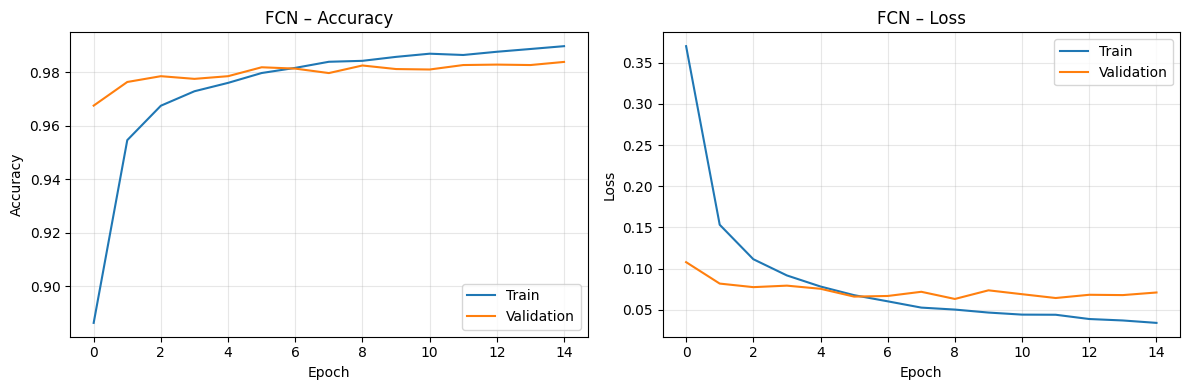

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and flatten to 784-dim vector
x_train = x_train.astype("float32") / 255.0   # shape: (60000, 28, 28)
x_test  = x_test.astype("float32")  / 255.0   # shape: (10000, 28, 28)

x_train_flat = x_train.reshape(-1, 784)        # shape: (60000, 784)
x_test_flat  = x_test.reshape(-1, 784)         # shape: (10000, 784)

print(f"Train: {x_train_flat.shape}, Test: {x_test_flat.shape}")

# Build FCN model
def build_fcn():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu", name="dense_1"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu", name="dense_2"),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu", name="dense_3"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax", name="output"),
    ], name="FCN")
    return model

fcn_model = build_fcn()
fcn_model.summary()

# Compile
fcn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Train
EPOCHS     = 15
BATCH_SIZE = 128

history_fcn = fcn_model.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

# Evaluate on test set
test_loss_fcn, test_acc_fcn = fcn_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nFCN  ->  Test accuracy: {test_acc_fcn:.4f}  |  Test loss: {test_loss_fcn:.4f}")

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_fcn.history["accuracy"],     label="Train")
axes[0].plot(history_fcn.history["val_accuracy"], label="Validation")
axes[0].set_title("FCN – Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_fcn.history["loss"],     label="Train")
axes[1].plot(history_fcn.history["val_loss"], label="Validation")
axes[1].set_title("FCN – Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fcn_learning_curves.png", dpi=150)
plt.show()

### 1b - Convolutional Neural Network

#### Instructions
- Implement and train a convolutional neural network (CNN) and use the following architecture:

```
ConvNet(
(conv1): Conv2d(1, 5, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
(pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
(conv2): Conv2d(5, 10, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
(fc1): Linear(in_features=490, out_features=32, bias=True)
(fc2): Linear(in_features=32, out_features=10, bias=True)
)
```



- Use the MNIST handwritten digit dataset

Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 5)      │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 10)     │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 490)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        15,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,432 (68.09 KB)

 Trainable params: 17,432 (68.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8618 - loss: 0.4687 - val_accuracy: 0.9638 - val_loss: 0.1212
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9636 - loss: 0.1233 - val_accuracy: 0.9785 - val_loss: 0.0778
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9741 - loss: 0.0868 - val_accuracy: 0.9788 - val_loss: 0.0744
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9789 - loss: 0.0691 - val_accuracy: 0.9808 - val_loss: 0.0630
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9815 - loss: 0.0607 - val_accuracy: 0.9840 - val_loss: 0.0546
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9838 - loss: 0.0522 - val_accuracy: 0.9863 - val_loss: 0.0487
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9861 - loss: 0.0459 - val_accuracy: 0.9842 - val_loss: 0.0502
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.

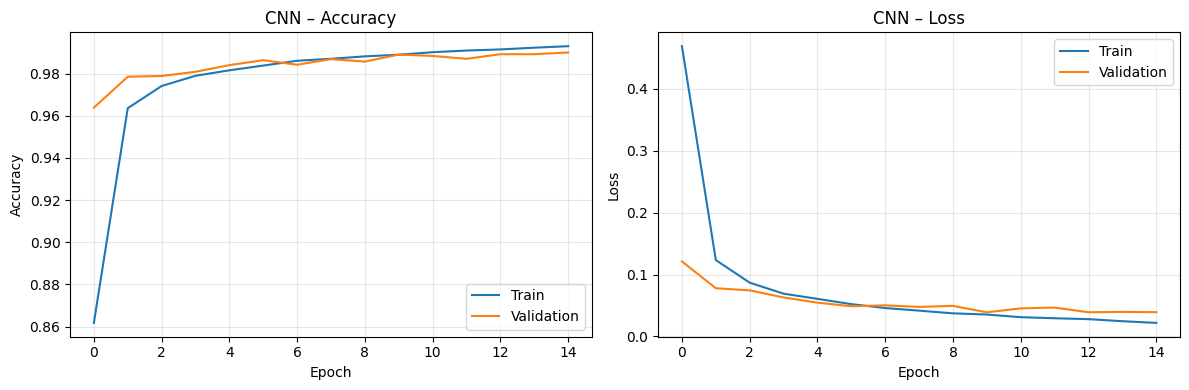


── Model Comparison ──
FCN  -> Test accuracy: 0.9820  |  Params: 567,434
CNN  -> Test accuracy: 0.9895  |  Params: 17,432


In [24]:
# Prepare data (keep 2D shape for CNN)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)   # shape: (60000, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)    # shape: (10000, 28, 28, 1)

print(f"Train: {x_train_cnn.shape}, Test: {x_test_cnn.shape}")

def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # conv1: 5 filters, 5x5 kernel, padding='same' → same as padding=2
        layers.Conv2D(5, kernel_size=5, strides=1, padding="same",
                      activation="relu", name="conv1"),
        # pool: MaxPool 2x2, stride=2
        layers.MaxPooling2D(pool_size=2, strides=2, name="pool1"),

        # conv2: 10 filters, 5x5 kernel, padding='same'
        layers.Conv2D(10, kernel_size=5, strides=1, padding="same",
                      activation="relu", name="conv2"),
        # pool: MaxPool 2x2, stride=2
        layers.MaxPooling2D(pool_size=2, strides=2, name="pool2"),

        # Flatten: 7x7x10 = 490
        layers.Flatten(name="flatten"),

        # fc1: 490 → 32
        layers.Dense(32, activation="relu", name="fc1"),

        # fc2: 32 → 10
        layers.Dense(10, activation="softmax", name="fc2"),
    ], name="CNN")
    return model

cnn_model = build_cnn()
cnn_model.summary()

# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Train
EPOCHS     = 15
BATCH_SIZE = 128

history_cnn = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

# Evaluate on test set
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)
print(f"\nCNN  → Test accuracy: {test_acc_cnn:.4f}  |  Test loss: {test_loss_cnn:.4f}")

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history["accuracy"],     label="Train")
axes[0].plot(history_cnn.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN – Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history["loss"],     label="Train")
axes[1].plot(history_cnn.history["val_loss"], label="Validation")
axes[1].set_title("CNN – Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_learning_curves.png", dpi=150)
plt.show()

# Compare FCN vs CNN
print("\n── Model Comparison ──")
print(f"FCN  -> Test accuracy: {test_acc_fcn:.4f}  |  Params: {fcn_model.count_params():,}")
print(f"CNN  -> Test accuracy: {test_acc_cnn:.4f}  |  Params: {cnn_model.count_params():,}")

## 2 - Analytic Computation of Lipschitz Constants


### 2a - Fully Connected Neural Network

#### Instructions
- Calculate the Lipschitz constant analytically for each layer of the FCN
- Calculate the Lipschitz constant analytically for the *complete* FCN

In [25]:
# Extract weights from each Dense layer
# Only Dense layers have learnable weights; ReLU has L=1, Dropout ignored
dense_layers = [layer for layer in fcn_model.layers
                if isinstance(layer, tf.keras.layers.Dense)]

print("── FCN: Lipschitz constant per layer ──")
print(f"{'Layer':<12} {'Shape':<20} {'Spectral Norm (L)'}")
print("-" * 50)

lipschitz_fcn_layers = []

for layer in dense_layers:
    W = layer.get_weights()[0]          # weight matrix, shape (in, out)
    # Spectral norm = largest singular value of W
    singular_values = np.linalg.svd(W, compute_uv=False)
    L_layer = singular_values[0]        # largest singular value
    lipschitz_fcn_layers.append(L_layer)
    print(f"{layer.name:<12} {str(W.shape):<20} L = {L_layer:.6f}")

# ReLU activation: L = 1 (does not amplify)
print("\nNote: ReLU activation has Lipschitz constant = 1 (no amplification)")

# Total Lipschitz constant = product of all layer constants
L_fcn_total = np.prod(lipschitz_fcn_layers)

print("\n── FCN: Total Lipschitz constant ──")
print(f"L_total = {' × '.join([f'{l:.4f}' for l in lipschitz_fcn_layers])}")
print(f"L_total = {L_fcn_total:.6f}")

── FCN: Lipschitz constant per layer ──
Layer        Shape                Spectral Norm (L)
--------------------------------------------------
dense_1      (784, 512)           L = 9.974194
dense_2      (512, 256)           L = 8.614435
dense_3      (256, 128)           L = 4.895230
output       (128, 10)            L = 2.316053

Note: ReLU activation has Lipschitz constant = 1 (no amplification)

── FCN: Total Lipschitz constant ──
L_total = 9.9742 × 8.6144 × 4.8952 × 2.3161
L_total = 974.150818


### 2b - Convolutional Neural Network

#### Instructions
- Calculate the Lipschitz constant analytically using the architecture-specific formula provided by Prof. Wunder in the lecture

In [26]:
import numpy as np

def cnn_layer_lipschitz(W, input_shape):
    """
    Compute Lipschitz constant of a Conv2D layer via Szegedy (2015).
    Uses 2D DFT over spatial dims, then max spectral norm over freq bins.

    W           : kernel weights, shape (kH, kW, c_in, c_out)
    input_shape : (H, W) of the feature map fed into this layer
    """
    kH, kW, c_in, c_out = W.shape
    H, W_size = input_shape

    # Zero-pad kernel to full feature map size (periodic extension)
    # then compute 2D DFT over spatial dims
    W_padded = np.zeros((H, W_size, c_in, c_out), dtype=complex)
    W_padded[:kH, :kW, :, :] = W     # place kernel in top-left corner

    # 2D FFT over spatial dimensions (axis 0 and 1)
    W_fft = np.fft.fft2(W_padded, axes=(0, 1))   # shape: (H, W, c_in, c_out)

    # For each frequency (v1, v2), form the c_out × c_in matrix A(v1,v2)
    # and compute its spectral norm (largest singular value)
    max_sv = 0.0
    for v1 in range(H):
        for v2 in range(W_size):
            A = W_fft[v1, v2, :, :].T    # shape: (c_out, c_in)
            sv = np.linalg.svd(A, compute_uv=False)
            max_sv = max(max_sv, sv[0])

    return max_sv


# Layer specs: (kernel_shape, input_feature_map_size)
# conv1: kernel (5,5,1,5),  input 28×28
# conv2: kernel (5,5,5,10), input 14×14  (after pool1)

conv_layers_info = [
    ("conv1", "conv1", (28, 28)),
    ("conv2", "conv2", (14, 14)),
]

print("── CNN: Lipschitz constant per layer ──")
print(f"{'Layer':<10} {'Kernel shape':<22} {'Input map':<14} {'L (Szegedy)'}")
print("-" * 60)

lipschitz_cnn_layers = []

for name, layer_name, inp_shape in conv_layers_info:
    layer = cnn_model.get_layer(layer_name)
    W = layer.get_weights()[0]          # shape: (kH, kW, c_in, c_out)
    L = cnn_layer_lipschitz(W, inp_shape)
    lipschitz_cnn_layers.append(L)
    print(f"{name:<10} {str(W.shape):<22} {str(inp_shape):<14} L = {L:.6f}")

# fc1, fc2: same as FCN → spectral norm of weight matrix
print()
fc_layers = [cnn_model.get_layer("fc1"), cnn_model.get_layer("fc2")]
for layer in fc_layers:
    W = layer.get_weights()[0]
    sv = np.linalg.svd(W, compute_uv=False)
    L = sv[0]
    lipschitz_cnn_layers.append(L)
    print(f"{layer.name:<10} {str(W.shape):<22} {'—':<14} L = {L:.6f}")

# ReLU = 1, MaxPool = 1 (non-expansive)
print("\nNote: ReLU and MaxPooling have Lipschitz constant = 1")

# Total
L_cnn_total = np.prod(lipschitz_cnn_layers)

print("\n── CNN: Total Lipschitz constant ──")
print(f"L_total = {' × '.join([f'{l:.4f}' for l in lipschitz_cnn_layers])}")
print(f"L_total = {L_cnn_total:.6f}")

── CNN: Lipschitz constant per layer ──
Layer      Kernel shape           Input map      L (Szegedy)
------------------------------------------------------------
conv1      (5, 5, 1, 5)           (28, 28)       L = 6.486395
conv2      (5, 5, 5, 10)          (14, 14)       L = 9.585041

fc1        (490, 32)              —              L = 4.404278
fc2        (32, 10)               —              L = 2.116710

Note: ReLU and MaxPooling have Lipschitz constant = 1

── CNN: Total Lipschitz constant ──
L_total = 6.4864 × 9.5850 × 4.4043 × 2.1167
L_total = 579.606783


## 3 - Numeric Computation of Lipschitz Constants

#### Instructions
- Calculate the Lipschitz constant numerically for the FCN and CNN

>**Hint**: You may use your code from the first exercise for this task, but you will likely need slight modifications.

**Question**: How can the approximation accuracy be improved?

In [27]:
def compute_lipschitz_numeric(model, x_data, input_shape_flat,
                               n_pairs=10000, batch_size=500, seed=42):
    """
    Estimate Lipschitz constant numerically by sampling random input pairs.

    model           : trained Keras model
    x_data          : pool of real inputs to sample from (normalized)
    input_shape_flat: shape to feed into model (flat for FCN, 4D for CNN)
    n_pairs         : number of random pairs to evaluate
    batch_size      : pairs per batch (memory management)
    seed            : random seed for reproducibility
    """
    rng = np.random.default_rng(seed)
    n_samples = len(x_data)
    max_ratio = 0.0

    for _ in range(0, n_pairs, batch_size):
        current_batch = min(batch_size, n_pairs)

        # Sample two independent sets of indices
        idx1 = rng.integers(0, n_samples, size=current_batch)
        idx2 = rng.integers(0, n_samples, size=current_batch)

        # Avoid identical pairs
        same = idx1 == idx2
        idx2[same] = (idx2[same] + 1) % n_samples

        x1 = x_data[idx1].reshape((current_batch,) + input_shape_flat)
        x2 = x_data[idx2].reshape((current_batch,) + input_shape_flat)

        # Model outputs
        f1 = model.predict(x1, verbose=0)   # shape: (batch, 10)
        f2 = model.predict(x2, verbose=0)

        # ||f(x1) - f(x2)||_2  /  ||x1 - x2||_2
        diff_output = np.linalg.norm(f1 - f2, axis=1)         # (batch,)
        diff_input  = np.linalg.norm(
            x1.reshape(current_batch, -1) - x2.reshape(current_batch, -1),
            axis=1
        )                                                       # (batch,)

        # Avoid division by zero
        valid = diff_input > 1e-10
        ratios = diff_output[valid] / diff_input[valid]
        if len(ratios) > 0:
            max_ratio = max(max_ratio, ratios.max())

    return max_ratio


# Run for FCN
print("Computing numeric Lipschitz constant for FCN ...")
L_fcn_numeric = compute_lipschitz_numeric(
    model            = fcn_model,
    x_data           = x_test_flat,
    input_shape_flat = (784,),
    n_pairs          = 10000,
)
print(f"FCN -> Numeric L  = {L_fcn_numeric:.6f}")
print(f"FCN -> Analytic L = {L_fcn_total:.6f}")
print(f"FCN -> Ratio (numeric/analytic) = {L_fcn_numeric/L_fcn_total:.4f}\n")

# Run for CNN
print("Computing numeric Lipschitz constant for CNN ...")
L_cnn_numeric = compute_lipschitz_numeric(
    model            = cnn_model,
    x_data           = x_test_cnn,
    input_shape_flat = (28, 28, 1),
    n_pairs          = 10000,
)
print(f"CNN -> Numeric L  = {L_cnn_numeric:.6f}")
print(f"CNN -> Analytic L = {L_cnn_total:.6f}")
print(f"CNN -> Ratio (numeric/analytic) = {L_cnn_numeric/L_cnn_total:.4f}\n")

# Summary table
print("── Summary ──")
print(f"{'Model':<8} {'Analytic L':>12} {'Numeric L':>12} {'Ratio':>8}")
print("-" * 45)
print(f"{'FCN':<8} {L_fcn_total:>12.4f} {L_fcn_numeric:>12.4f} {L_fcn_numeric/L_fcn_total:>8.4f}")
print(f"{'CNN':<8} {L_cnn_total:>12.4f} {L_cnn_numeric:>12.4f} {L_cnn_numeric/L_cnn_total:>8.4f}")

# Question
print("""
Q: How can the approximation accuracy be improved?
1. Increase n_pairs: more random pairs -> better chance of hitting the worst-case input pair that achieves the true maximum ratio.

2. Use adversarial search: instead of random pairs, use gradient-based optimization to actively search for the pair that maximizes the ratio.

3. Sample near decision boundaries: pairs close to class boundaries are more likely to expose large output differences for small input changes.

4. Use the full training set: larger input pool -> more diverse pairs.
""")

Computing numeric Lipschitz constant for FCN ...
FCN -> Numeric L  = 0.281811
FCN -> Analytic L = 974.150818
FCN -> Ratio (numeric/analytic) = 0.0003

Computing numeric Lipschitz constant for CNN ...
CNN -> Numeric L  = 0.265041
CNN -> Analytic L = 579.606783
CNN -> Ratio (numeric/analytic) = 0.0005

── Summary ──
Model      Analytic L    Numeric L    Ratio
---------------------------------------------
FCN          974.1508       0.2818   0.0003
CNN          579.6068       0.2650   0.0005

Q: How can the approximation accuracy be improved?
1. Increase n_pairs: more random pairs -> better chance of hitting the worst-case input pair that achieves the true maximum ratio.

2. Use adversarial search: instead of random pairs, use gradient-based optimization to actively search for the pair that maximizes the ratio.

3. Sample near decision boundaries: pairs close to class boundaries are more likely to expose large output differences for small input changes.

4. Use the full training set: larg

## 4 - Adversarial Attacks

### 4a - Fast Gradient Sign Method

The fast gradient sign method (FGSM) attack is a white box attack whose goal it is to ensure misclassification. A white box attack is where the attacker has complete access to the model being attacked. The FGSM attack works by using the gradients of a neural network to create an adversarial example. For an input image, the method uses the gradients of the loss with respect to the input image to create a new image that maximises the loss, eventually resulting in a missclassification of the original image.

<br>

The FGSM attack can be summarised using the following expression:

> $adv\_x = x + \epsilon*\text{sign}(\nabla_xJ(\theta, x, y))$
>
>where:
>> $adv_x$ : Adversarial image\
> $x$ : Original input image\
> $y$ : Original input label\
> $\epsilon$: Constant controlling the magnitude of the perturbation\
> $\theta$: Model parameters\
> $J$: Loss

<br>

#### Instructions

- Conduct this attack on your FCN from task 1a and a new CNN trained on CIFAR-10
- Start by selecting an image from the dataset
- Implement the FGSM to generate an adversarial example from the selected image
- Compare the model's outputs on the original and modified image (observe changes in prediction confidence and accuracy)
- Visualize the images and their corresponding predictions

>**Hint**: You may need to experiment with $\epsilon$ to find a suitable trade-off between image quality and model confidence. Implement an algorithm that finds the (approximate) minimum required $\epsilon$ to achieve a misclassification.

**Question**: Why does the FGSM use only the sign of the gradients instead of following the gradients themselves?

In [28]:
# Load and preprocess CIFAR-10
(x_train_c, y_train_c), (x_test_c, y_test_c) = keras.datasets.cifar10.load_data()

x_train_c = x_train_c.astype("float32") / 255.0   # shape: (50000, 32, 32, 3)
x_test_c  = x_test_c.astype("float32")  / 255.0   # shape: (10000, 32, 32, 3)
y_train_c = y_train_c.flatten()
y_test_c  = y_test_c.flatten()

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

print(f"CIFAR-10 Train: {x_train_c.shape}, Test: {x_test_c.shape}")

# Build CNN for CIFAR-10
def build_cifar_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="CIFAR_CNN")
    return model

cifar_cnn = build_cifar_cnn()
cifar_cnn.summary()

cifar_cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_cifar = cifar_cnn.fit(
    x_train_c, y_train_c,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

loss_c, acc_c = cifar_cnn.evaluate(x_test_c, y_test_c, verbose=0)
print(f"\nCIFAR-10 CNN → Test accuracy: {acc_c:.4f}  |  Test loss: {loss_c:.4f}")

CIFAR-10 Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


Model: "CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3668 - loss: 1.7195 - val_accuracy: 0.5264 - val_loss: 1.3149
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5319 - loss: 1.3028 - val_accuracy: 0.6278 - val_loss: 1.0491
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6008 - loss: 1.1195 - val_accuracy: 0.6720 - val_loss: 0.9404
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6398 - loss: 1.0121 - val_accuracy: 0.7020 - val_loss: 0.8653
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6712 - loss: 0.9313 - val_accuracy: 0.7166 - val_loss: 0.8123
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6929 - loss: 0.8681 - val_accuracy: 0.7306 - val_loss: 0.7771
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7159 - loss: 0.8105 - val_accuracy: 0.7484 - val_loss: 0.7339
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7298 - loss: 0.7700 - val_acc


── FCN MNIST ──
True label    : 7
Original pred : 7 (100.0%)
Min ε for misclassification: 0.0637
Adversarial pred at min ε  : 3 (35.0%)


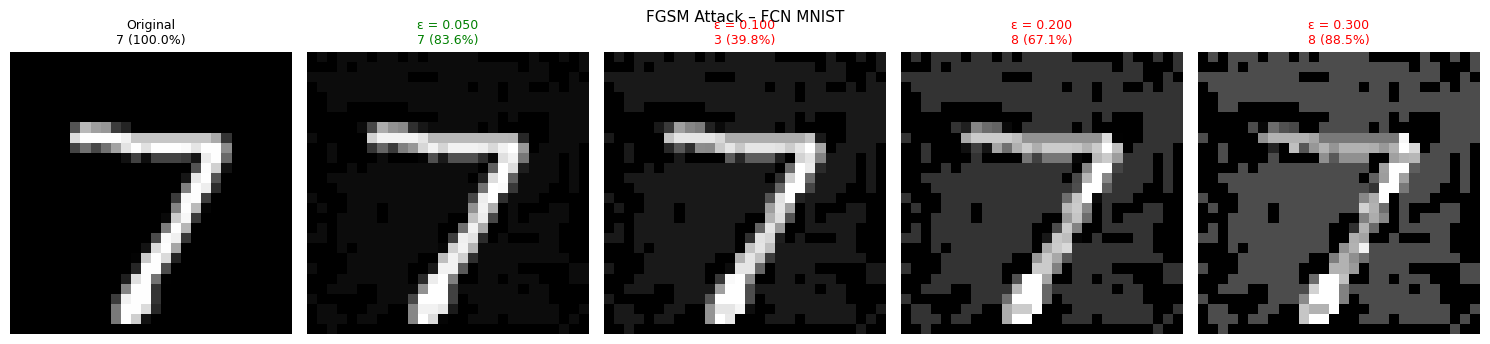


── CNN CIFAR-10 ──
True label    : cat
Original pred : cat (60.6%)
Min ε for misclassification: 0.0008
Adversarial pred at min ε  : dog (48.0%)


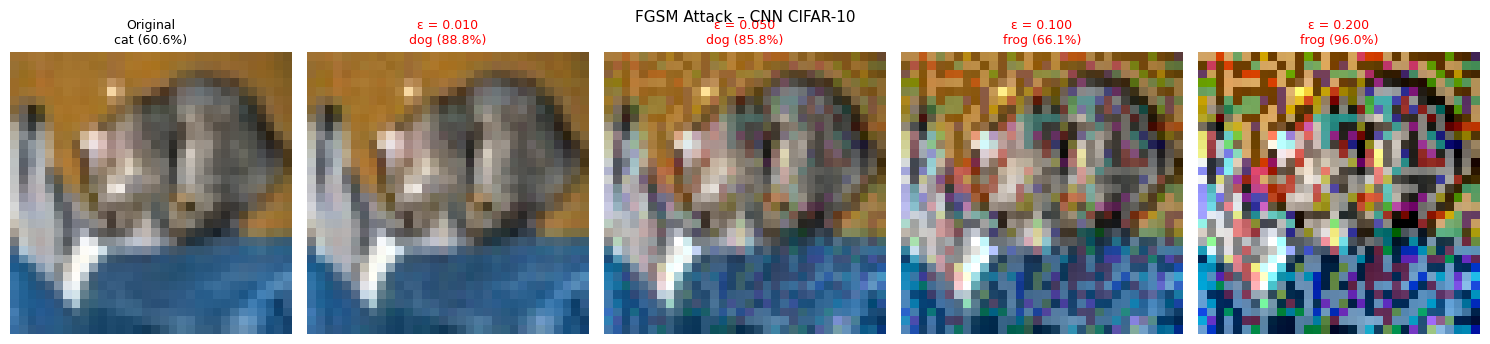


Q: Why does the FGSM use only the sign of the gradients instead of following the gradients themselves?
1. Uniform perturbation magnitude: sign() maps every gradient to ±1, so each pixel is perturbed by exactly ε, the total perturbation budget is fully and evenly used across all dimensions.

2. Avoids scale imbalance: raw gradients vary wildly in magnitude across pixels. Large-gradient pixels would dominate and waste the budget; small-gradient pixels would barely move.

3. L∞ optimality: FGSM is designed to maximize loss under an L∞ constraint (max pixel change ≤ ε). The optimal solution under L∞ is exactly x + ε·sign(∇), not the raw gradient direction.

4. Computational simplicity: one forward + one backward pass is enough, no iterative optimization needed.



In [29]:
def fgsm_attack(model, x, y_true, epsilon):
    """
    Generate adversarial example using FGSM.
    x      : single image, shape (1, H, W, C) or (1, 784), float32
    y_true : true label (integer)
    epsilon: perturbation magnitude
    Returns adversarial image (same shape as x), clipped to [0,1]
    """
    x_tensor = tf.cast(x, tf.float32)
    y_tensor = tf.expand_dims(tf.cast(y_true, tf.int32), 0)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        pred = model(x_tensor, training=False)
        loss = keras.losses.sparse_categorical_crossentropy(y_tensor, pred)

    gradient = tape.gradient(loss, x_tensor)          # ∇_x J(θ, x, y)
    signed_grad = tf.sign(gradient)                   # sign(∇_x J)
    adv_x = x_tensor + epsilon * signed_grad          # adv_x = x + ε·sign(∇)
    adv_x = tf.clip_by_value(adv_x, 0.0, 1.0)        # keep in valid range
    return adv_x.numpy()


def find_min_epsilon(model, x, y_true,
                     eps_min=0.0, eps_max=1.0, n_steps=20):
    """
    Binary search for the minimum epsilon that causes misclassification.
    """
    for _ in range(n_steps):
        eps_mid = (eps_min + eps_max) / 2
        adv = fgsm_attack(model, x, y_true, eps_mid)
        pred_label = np.argmax(model.predict(adv, verbose=0))
        if pred_label != y_true:
            eps_max = eps_mid    # misclassified → try smaller
        else:
            eps_min = eps_mid    # still correct  → need larger
    return eps_max


def run_fgsm_demo(model, x_sample, y_true, label_names,
                  eps_list, model_name="Model"):
    """
    Full FGSM demo: find min epsilon, visualize original vs adversarial.
    """
    x_in = x_sample[np.newaxis]                       # add batch dim

    # Original prediction
    orig_pred = model.predict(x_in, verbose=0)[0]
    orig_label = np.argmax(orig_pred)
    orig_conf  = orig_pred[orig_label]

    # Find minimum epsilon for misclassification
    eps_min = find_min_epsilon(model, x_in, y_true)
    adv_min = fgsm_attack(model, x_in, y_true, eps_min)
    adv_pred_min = model.predict(adv_min, verbose=0)[0]
    adv_label_min = np.argmax(adv_pred_min)

    print(f"\n── {model_name} ──")
    print(f"True label    : {label_names[y_true]}")
    print(f"Original pred : {label_names[orig_label]} ({orig_conf*100:.1f}%)")
    print(f"Min ε for misclassification: {eps_min:.4f}")
    print(f"Adversarial pred at min ε  : {label_names[adv_label_min]} "
          f"({adv_pred_min[adv_label_min]*100:.1f}%)")

    # Visualize across multiple epsilon values
    n_eps = len(eps_list)
    fig, axes = plt.subplots(1, n_eps + 1, figsize=(3 * (n_eps + 1), 3.5))

    # Original image
    ax = axes[0]
    img_show = x_sample if x_sample.ndim == 3 else x_sample.reshape(28, 28)
    ax.imshow(img_show, cmap="gray" if img_show.ndim == 2 else None)
    ax.set_title(f"Original\n{label_names[orig_label]} ({orig_conf*100:.1f}%)",
                 fontsize=9)
    ax.axis("off")

    # Adversarial images at each epsilon
    for i, eps in enumerate(eps_list):
        adv = fgsm_attack(model, x_in, y_true, eps)
        pred = model.predict(adv, verbose=0)[0]
        pred_label = np.argmax(pred)
        conf = pred[pred_label]

        adv_show = adv[0] if adv[0].ndim == 3 else adv[0].reshape(28, 28)
        axes[i+1].imshow(adv_show,
                         cmap="gray" if adv_show.ndim == 2 else None)
        color = "red" if pred_label != y_true else "green"
        axes[i+1].set_title(
            f"ε = {eps:.3f}\n{label_names[pred_label]} ({conf*100:.1f}%)",
            fontsize=9, color=color
        )
        axes[i+1].axis("off")

    plt.suptitle(f"FGSM Attack – {model_name}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"fgsm_{model_name.lower().replace(' ','_')}.png", dpi=150)
    plt.show()


# Demo on FCN (MNIST)
MNIST_CLASSES = [str(i) for i in range(10)]
sample_idx_mnist = 0
x_mnist_sample = x_test_flat[sample_idx_mnist]         # shape: (784,)
y_mnist_true   = int(y_test[sample_idx_mnist])

run_fgsm_demo(
    model       = fcn_model,
    x_sample    = x_mnist_sample,
    y_true      = y_mnist_true,
    label_names = MNIST_CLASSES,
    eps_list    = [0.05, 0.10, 0.20, 0.30],
    model_name  = "FCN MNIST",
)

# Demo on CIFAR-10 CNN
sample_idx_cifar = 0
x_cifar_sample = x_test_c[sample_idx_cifar]            # shape: (32, 32, 3)
y_cifar_true   = int(y_test_c[sample_idx_cifar])

run_fgsm_demo(
    model       = cifar_cnn,
    x_sample    = x_cifar_sample,
    y_true      = y_cifar_true,
    label_names = CIFAR10_CLASSES,
    eps_list    = [0.01, 0.05, 0.10, 0.20],
    model_name  = "CNN CIFAR-10",
)

# Question
print("""
Q: Why does the FGSM use only the sign of the gradients instead of following the gradients themselves?
1. Uniform perturbation magnitude: sign() maps every gradient to ±1, so each pixel is perturbed by exactly ε, the total perturbation budget is fully and evenly used across all dimensions.

2. Avoids scale imbalance: raw gradients vary wildly in magnitude across pixels. Large-gradient pixels would dominate and waste the budget; small-gradient pixels would barely move.

3. L∞ optimality: FGSM is designed to maximize loss under an L∞ constraint (max pixel change ≤ ε). The optimal solution under L∞ is exactly x + ε·sign(∇), not the raw gradient direction.

4. Computational simplicity: one forward + one backward pass is enough, no iterative optimization needed.
""")

### 4b - Targeted Adversarial Noise Tuning

#### Instructions
- Use your FCN from task 1a
- Initialize a matrix of MNIST shape with random noise $\epsilon$
- Use an optimizer to tune the values of $\epsilon$ to make the neural network misclassify $x+\epsilon$ to a target class that is not the original class
- Use weight decay in your optimizer to limit the magnitude of the noise
- Minimize the cross-entropy loss of the model's prediction on the perturbed image and the intended target label
- Visualize your findings

>**Hint**: Tuning the noise matrix is very similar to tuning linear layers in neural networks.

True label: 7  |  Target label: 0

  Step    0 | loss: 23.2908 | pred: 7 (100.0%)
  Step  100 | loss: 0.0305 | pred: 0 (98.7%)
  Step  200 | loss: 0.0219 | pred: 0 (99.6%)
  Step  300 | loss: 0.0193 | pred: 0 (99.8%)
  Step  400 | loss: 0.0177 | pred: 0 (99.8%)


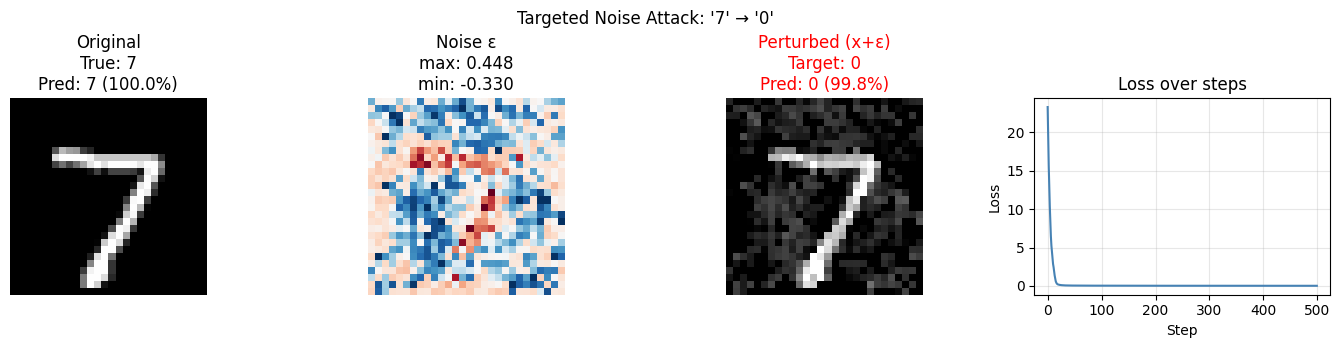


Attack SUCCESS
  Original  → 7  (100.0%)
  Perturbed → 0 (99.8%)
  Noise L2 norm: 3.8562
  Noise L∞ norm: 0.4476


In [30]:
def targeted_noise_attack(model, x_original, y_target,
                          n_steps=500, lr=0.01, weight_decay=1e-3,
                          verbose=True):
    """
    Optimize a noise matrix ε to make model predict y_target.

    model      : trained FCN (fixed weights)
    x_original : original image, shape (784,), float32
    y_target   : desired wrong class (integer)
    n_steps    : optimization steps
    lr         : learning rate
    weight_decay: L2 penalty on ε to limit magnitude
    """
    # Initialize noise with small random values
    epsilon = tf.Variable(
        tf.random.uniform(x_original.shape, minval=-0.1, maxval=0.1),
        trainable=True
    )

    optimizer = keras.optimizers.Adam(learning_rate=lr)
    y_target_tensor = tf.constant([y_target], dtype=tf.int32)

    loss_history = []

    for step in range(n_steps):
        with tf.GradientTape() as tape:
            # Perturbed image, clipped to valid range [0, 1]
            x_perturbed = tf.clip_by_value(x_original + epsilon, 0.0, 1.0)

            # Model prediction on perturbed image
            pred = model(tf.expand_dims(x_perturbed, 0), training=False)

            # Cross-entropy loss toward TARGET class
            ce_loss = keras.losses.sparse_categorical_crossentropy(
                y_target_tensor, pred
            )

            # Weight decay: L2 penalty on epsilon magnitude
            l2_loss = weight_decay * tf.reduce_sum(tf.square(epsilon))

            total_loss = ce_loss + l2_loss

        # Gradient w.r.t. epsilon only (model weights are NOT updated)
        grads = tape.gradient(total_loss, epsilon)
        optimizer.apply_gradients([(grads, epsilon)])

        loss_history.append(float(total_loss))

        if verbose and step % 100 == 0:
            pred_label = np.argmax(pred.numpy())
            conf = pred.numpy()[0][pred_label]
            print(f"  Step {step:4d} | loss: {float(total_loss):.4f} | "
                  f"pred: {pred_label} ({conf*100:.1f}%)")

    return epsilon.numpy(), loss_history


def visualize_noise_attack(model, x_original, y_true, y_target,
                           epsilon, loss_history, label_names):
    """
    Visualize: original | noise | perturbed image + predictions
    """
    x_perturbed = np.clip(x_original.numpy() + epsilon, 0.0, 1.0)

    orig_pred  = model.predict(x_original.numpy()[np.newaxis], verbose=0)[0]
    adv_pred   = model.predict(x_perturbed[np.newaxis],        verbose=0)[0]

    orig_label = np.argmax(orig_pred)
    adv_label  = np.argmax(adv_pred)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

    # Original image
    axes[0].imshow(x_original.numpy().reshape(28, 28), cmap="gray")
    axes[0].set_title(
        f"Original\nTrue: {label_names[y_true]}\n"
        f"Pred: {label_names[orig_label]} ({orig_pred[orig_label]*100:.1f}%)"
    )
    axes[0].axis("off")

    # Noise (ε)
    eps_show = epsilon.reshape(28, 28)
    axes[1].imshow(eps_show, cmap="RdBu", vmin=-0.3, vmax=0.3)
    axes[1].set_title(
        f"Noise ε\nmax: {eps_show.max():.3f}\nmin: {eps_show.min():.3f}"
    )
    axes[1].axis("off")

    # Perturbed image
    color = "red" if adv_label != y_true else "green"
    axes[2].imshow(x_perturbed.reshape(28, 28), cmap="gray")
    axes[2].set_title(
        f"Perturbed (x+ε)\nTarget: {label_names[y_target]}\n"
        f"Pred: {label_names[adv_label]} ({adv_pred[adv_label]*100:.1f}%)",
        color=color
    )
    axes[2].axis("off")

    # Loss curve
    axes[3].plot(loss_history, color="steelblue")
    axes[3].set_title("Loss over steps")
    axes[3].set_xlabel("Step")
    axes[3].set_ylabel("Loss")
    axes[3].grid(True, alpha=0.3)

    plt.suptitle(
        f"Targeted Noise Attack: '{label_names[y_true]}' → '{label_names[y_target]}'",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig("noise_tuning_attack.png", dpi=150)
    plt.show()

    print(f"\nAttack {'SUCCESS' if adv_label == y_target else 'FAILED'}")
    print(f"  Original  → {label_names[y_true]}  ({orig_pred[y_true]*100:.1f}%)")
    print(f"  Perturbed → {label_names[adv_label]} ({adv_pred[adv_label]*100:.1f}%)")
    print(f"  Noise L2 norm: {np.linalg.norm(epsilon):.4f}")
    print(f"  Noise L∞ norm: {np.abs(epsilon).max():.4f}")


# Run attack
MNIST_CLASSES = [str(i) for i in range(10)]

# Pick a sample: true label = 7, target = 3
sample_idx = 0
x_orig  = tf.constant(x_test_flat[sample_idx], dtype=tf.float32)
y_true  = int(y_test[sample_idx])
y_target = (y_true + 3) % 10      # target = a different class

print(f"True label: {y_true}  |  Target label: {y_target}\n")

epsilon_opt, loss_hist = targeted_noise_attack(
    model        = fcn_model,
    x_original   = x_orig,
    y_target     = y_target,
    n_steps      = 500,
    lr           = 0.01,
    weight_decay = 1e-3,
)

visualize_noise_attack(
    model        = fcn_model,
    x_original   = x_orig,
    y_true       = y_true,
    y_target     = y_target,
    epsilon      = epsilon_opt,
    loss_history = loss_hist,
    label_names  = MNIST_CLASSES,
)